# Basic Querying

This tutorial loads halo and galaxy catalogs and computes some basic statistical distributions.

First, let's load the relevant libraries:

In [2]:
%matplotlib inline
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt

First, let's load a halo catalog and inspect the fields that are available:

In [76]:
halos = oc.open("haloproperties.hdf5")
for field in halos.columns: print(field)

sod_halo_mass_dm
sod_halo_Y500c
sod_halo_com_y_gas
sod_halo_RVir
sod_halo_GasFracShell2500c
sod_halo_MGas500c
sod_halo_com_x_gas
sod_halo_mmagn_id
fof_halo_center_x
sod_halo_mass_sfgas
sod_halo_mass_star
sod_halo_1D_vel_disp
sod_halo_L500cBolo
sod_halo_com_vy
sod_halo_T500cBolo
sod_halo_mass_agn
fof_halo_center_y
sod_halo_L500cRosatEx
sod_halo_com_z
sod_halo_mass
fof_halo_com_x
sod_halo_mass_nHI
sod_halo_L500cRosat
sod_halo_radius
sod_halo_bhr
sod_halo_mmagn_mass
sod_halo_com_x
fof_halo_com_vx
sod_halo_Y5R500c
sod_halo_com_vx
fof_halo_1D_vel_disp
sod_halo_com_y
sod_halo_com_z_gas
sod_halo_MGas200m
sod_halo_MVir
fof_halo_mass
sod_halo_sfr
sod_halo_cdelta_error
sod_halo_L500cErositaHiEx
fof_halo_com_y
block
sod_halo_core_cusp
sod_halo_L500cErositaLoEx
sod_halo_cdelta
sod_halo_L500cBoloEx
sod_halo_com_z_dm
sod_halo_MGasHot500c
sod_halo_L500cErositaHi
sod_halo_com_vz
sod_halo_MStar500c
sod_halo_MGas2500c
sod_halo_com_y_dm
sod_halo_R2500c
sod_halo_T500cBoloEx
sod_halo_com_x_dm
sod_halo_core

Now, let's compute distributions for (1) halo total mass (2) halo gas mass, and (3) halo stellar mass:

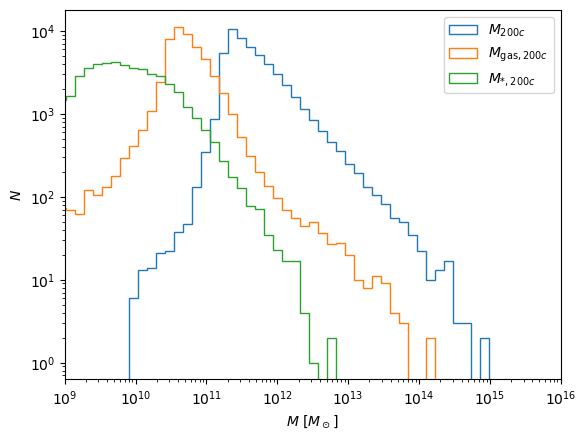

In [78]:
halo_data = halos.get_data()

hist_bins = np.geomspace(1e8,1e16,64)
plt.hist(halo_data["sod_halo_mass"], histtype="step", bins=hist_bins, label=r"$M_{200c}$")
plt.hist(halo_data["sod_halo_mass_gas"], histtype="step", bins=hist_bins, label=r"$M_{\text{gas}, 200c}$")
plt.hist(halo_data["sod_halo_mass_star"], histtype="step", bins=hist_bins, label=r"$M_{*, 200c}$")

plt.xlim(1e9, 1e16)
plt.xlabel(r"$M\,\,[M_\odot]$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

Now, let's compute a galaxy mass function for this dataset. For this, we need to load the galaxy catalog:

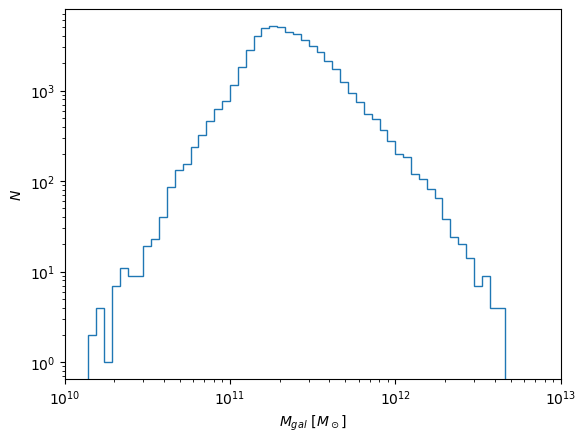

In [77]:
gal_data = oc.open("galaxyproperties.hdf5").get_data()

hist_bins = np.geomspace(1e10,1e13,64)
plt.hist(gal_data["gal_mass"], histtype="step", bins=hist_bins)

plt.xlim(1e10, 1e13)
plt.xlabel(r"$M_{gal}\,\,[M_\odot]$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')

plt.show()

What if we wanted to compute a distribution for a custom field? We can do this using the `evaluate` function to insert new columns into the dataset. Let's compute halo gas fractions within R200c.

In [86]:
# reload halo catalog
halos = oc.open("haloproperties.hdf5")

def fgas(sod_halo_mass_gas, sod_halo_mass):
    return sod_halo_mass_gas / sod_halo_mass
    
halos = halos.evaluate(fgas, insert=True, vectorize=True)

There is now a new column in the halo properties dataset called "fgas". Let's plot it:

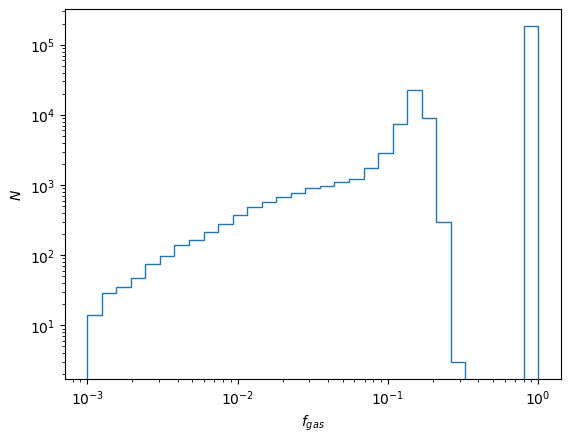

In [81]:
halo_data = halos.get_data()

hist_bins = np.geomspace(1e-3, 1e0, 32)
plt.hist(halo_data["fgas"], histtype="step", bins=hist_bins)

plt.xlabel(r"$f_{gas}$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')

plt.show()

If we directly plot `halo_data["sod_halo_mass_gas"]/halo_data["sod_halo_mass"]`, you can see we get the same result as plotting the derived column `"fgas"`:

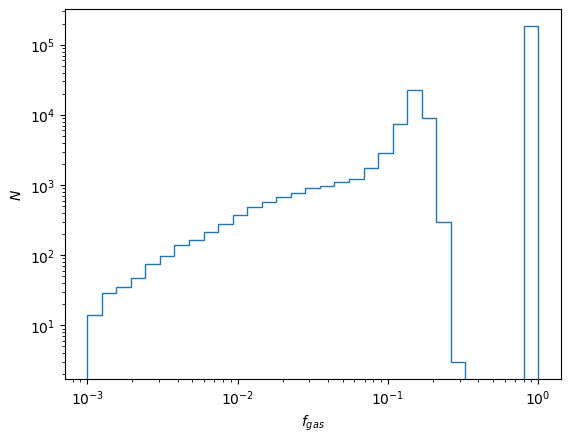

In [85]:
plt.hist(halo_data["sod_halo_mass_gas"]/halo_data["sod_halo_mass"], histtype="step", bins=hist_bins)

plt.xlabel(r"$f_{gas}$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')

plt.show()